<a href="https://colab.research.google.com/github/fcoliveira-utfpr/aquacrop_ml/blob/main/12_analise_milho_economica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Configuração e carregamento dos dados

Este notebook usa **só o cenário de custo fixo "Custo Operacional (CONAB)"** (`09b`/`10b`) como
referência econômica — não compara mais com os cenários 100%/rateio 50%/proporcional que as
versões anteriores deste notebook mostravam lado a lado.

In [1]:
!pip install -q geobr unidecode

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import geobr
import unidecode
import matplotlib.ticker as mticker

BASE_URL = "https://raw.githubusercontent.com/fcoliveira-utfpr/aquacrop_ml/main/"

def carregar(nome_arquivo, **kwargs):
    '''Lê um CSV diretamente do GitHub (raw) para um DataFrame pandas.'''
    return pd.read_csv(BASE_URL + nome_arquivo, **kwargs)


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Carregamento de todos os resultados relevantes gerados pelos notebooks 05, 09/09b e 10b do
# repositório — eixo econômico é só o cenário Custo Operacional (CONAB).

# Desempenho do modelo Extra Trees na predição de produtividade (Notebook 05)
resultados_inferencia = carregar("resultados_inferencia.csv")

# Produtividade prevista por município, ano-safra e data de semeadura (Notebook 05/09)
previsoes = carregar("previsoes_oeste_pr.csv")

# Risco climático (ISNA) por combinação município x data de semeadura (Notebook 09, Seção 5)
risco_clima = carregar("risco_climatico_oeste_pr.csv")

# Risco econômico (margem) — cenário Custo Operacional (CONAB), único cenário usado (Notebook 09b)
risco_economico = carregar("risco_economico_oeste_pr_operacional_conab.csv")

# Matriz integrada com os três eixos + PCA + TOPSIS, cenário Custo Operacional (CONAB) (Notebook 10b)
matriz_topsis = carregar("matriz_topsis_oeste_pr_operacional_conab.csv")

# Recomendação final — abordagem ordinal por tercis (Notebook 10b)
melhor_data_ordinal = carregar("melhor_data_semeadura_integrada_operacional_conab.csv")

# Recomendação final — abordagem TOPSIS (Notebook 10b)
melhor_data_topsis = carregar("melhor_data_semeadura_topsis_operacional_conab.csv")

# Padronização do formato da data de semeadura: os valores originais vêm com uma barra
# sobrando no final (ex.: "05/02/"), resquício da exportação. Removemos aqui para leitura correta.
for df in [risco_clima, risco_economico, matriz_topsis, melhor_data_ordinal, melhor_data_topsis, previsoes]:
    df["data_semeadura"] = df["data_semeadura"].str.rstrip("/")

print("risco_climatico_oeste_pr.csv                       :", risco_clima.shape)
print("risco_economico_oeste_pr_operacional_conab.csv      :", risco_economico.shape)
print("matriz_topsis_oeste_pr_operacional_conab.csv        :", matriz_topsis.shape)
print("melhor_data (ordinal, operacional_conab)            :", melhor_data_ordinal.shape)
print("melhor_data (TOPSIS, operacional_conab)              :", melhor_data_topsis.shape)
print("previsoes_oeste_pr.csv                              :", previsoes.shape)
print("resultados_inferencia.csv                           :", resultados_inferencia.shape)
print()
print("Municípios avaliados:", matriz_topsis["municipio"].nunique())
print("Datas de semeadura avaliadas:", sorted(matriz_topsis["data_semeadura"].unique()))

risco_climatico_oeste_pr.csv                       : (300, 12)
risco_economico_oeste_pr_operacional_conab.csv      : (300, 6)
matriz_topsis_oeste_pr_operacional_conab.csv        : (300, 25)
melhor_data (ordinal, operacional_conab)            : (50, 8)
melhor_data (TOPSIS, operacional_conab)              : (50, 6)
previsoes_oeste_pr.csv                              : (8100, 4)
resultados_inferencia.csv                           : (24, 9)

Municípios avaliados: 50
Datas de semeadura avaliadas: ['05/02', '05/03', '15/02', '15/03', '25/02', '25/03']


## 2. Gráfico dos custos e preços deflacionados e real

Custo fixo aqui já é o do cenário **Operacional (CONAB)** — `custo_fixo_operacional_real`
(`09b`), não o `custo_fixo_real` original (que atribui 100% da Renda de Fatores/terra ao milho
safrinha). Custo variável não muda entre cenários (não é afetado pela questão da terra
duplicada — ver `09b`, seção 2).

In [3]:
custoderal = carregar("custo_deral_operacional_conab.csv")
preco = carregar("precos_milho_pr.csv")

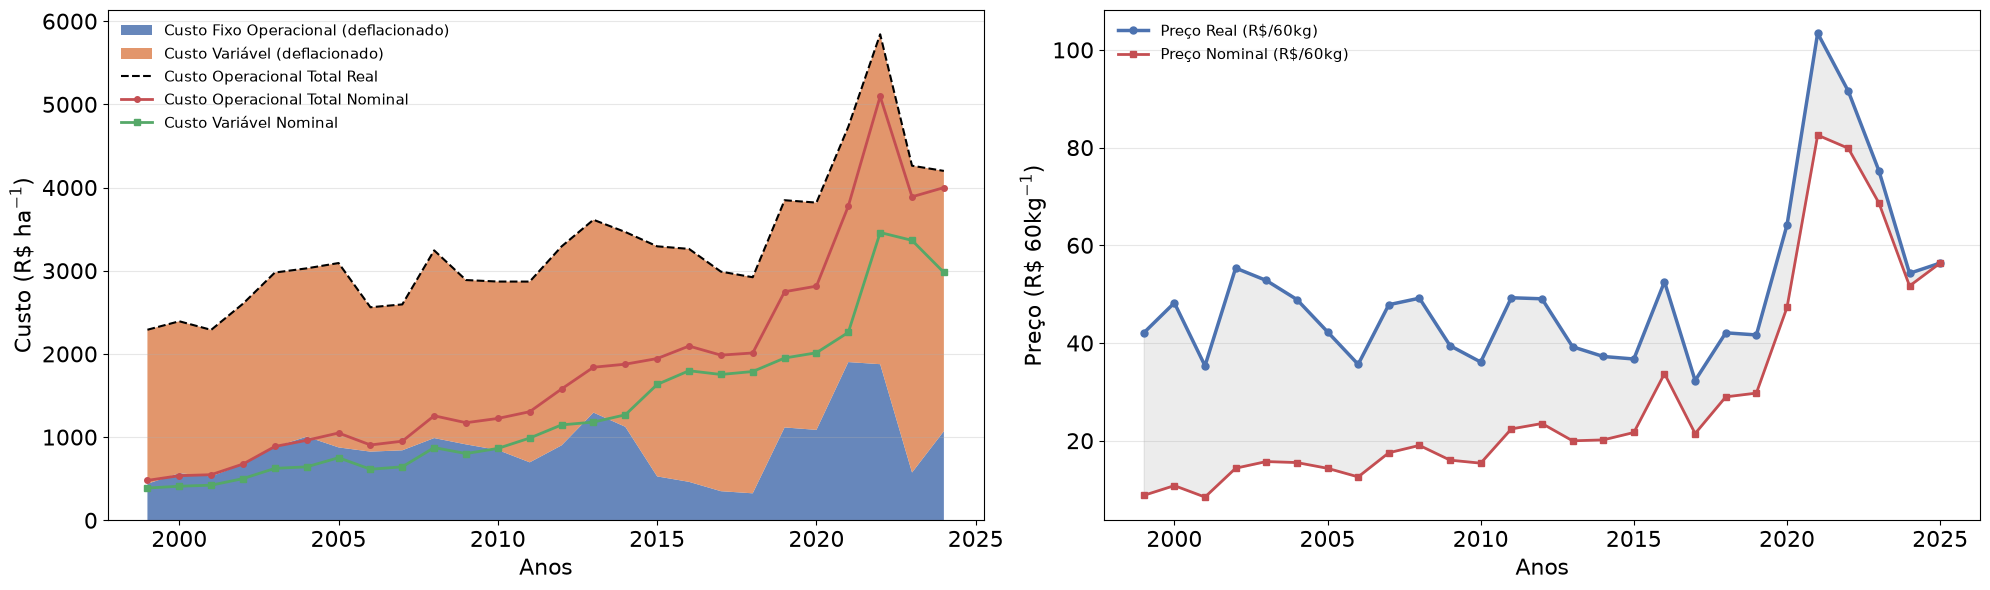

In [4]:
# Ordenar por ano
df_custo = custoderal.sort_values("ano")
df_preco = preco.sort_values("ano")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# ========== PAINEL ESQUERDO: CUSTO (cenário Operacional CONAB) ==========
ax1.stackplot(
    df_custo["ano"],
    df_custo["custo_fixo_operacional_real"],
    df_custo["custo_rs_ha_variavel_real"],
    labels=["Custo Fixo Operacional (deflacionado)", "Custo Variável (deflacionado)"],
    colors=["#4C72B0", "#DD8452"],
    alpha=0.85,
)

ax1.plot(
    df_custo["ano"],
    df_custo["custo_operacional_total_real"],
    color="black", linewidth=1.5, linestyle="--",
    label="Custo Operacional Total Real",
)

ax1.plot(
    df_custo["ano"],
    df_custo["custo_operacional_total_nominal"],
    color="#C44E52", linewidth=2, linestyle="-", marker="o", markersize=4,
    label="Custo Operacional Total Nominal",
)

ax1.plot(
    df_custo["ano"],
    df_custo["custo_rs_ha_variavel_nominal"],
    color="#55A868", linewidth=2, linestyle="-", marker="s", markersize=4,
    label="Custo Variável Nominal",
)

ax1.set_xlabel("Anos", fontsize=16)
ax1.set_ylabel(r"Custo (R\$ ha$^{-1}$)", fontsize=16)
ax1.legend(loc="upper left", frameon=False, ncol=1, fontsize=11)
ax1.grid(axis="y", alpha=0.3)
ax1.tick_params(axis="x", labelsize=16)
ax1.tick_params(axis="y", labelsize=16)

# ========== PAINEL DIREITO: PREÇO (não muda entre cenários de custo) ==========
ax2.plot(
    df_preco["ano"],
    df_preco["preco_rs_60kg_real"],
    color="#4C72B0", linewidth=2.5, marker="o", markersize=5,
    label="Preço Real (R$/60kg)",
)

ax2.plot(
    df_preco["ano"],
    df_preco["preco_rs_60kg_nominal"],
    color="#C44E52", linewidth=2, linestyle="-", marker="s", markersize=4,
    label="Preço Nominal (R$/60kg)",
)

ax2.fill_between(
    df_preco["ano"],
    df_preco["preco_rs_60kg_real"],
    df_preco["preco_rs_60kg_nominal"],
    color="gray", alpha=0.15,
)

ax2.set_xlabel("Anos", fontsize=16)
ax2.set_ylabel(r"Preço (R\$ 60kg$^{-1}$)", fontsize=16)
ax2.legend(loc="upper left", frameon=False, fontsize=11)
ax2.grid(axis="y", alpha=0.3)
ax2.tick_params(axis="x", labelsize=16)
ax2.tick_params(axis="y", labelsize=16)

plt.tight_layout()
plt.show()

## 3. Risco climático

Eixo climático (ISNA/ZARC) — não depende do cenário de custo, idêntico às versões anteriores deste
notebook.

In [5]:
risco_clima

,municipio,data_semeadura,isna_medio,isna_desvio,n_anos,freq_evento_adverso,freq_deficit_faseI,freq_deficit_faseIII,freq_frio_floracao,freq_geada,freq_excesso_faseIV,risco_climatico
0,Anahy,05/02,0.749378,0.116693,27,0.444444,0.148148,0.370370,0.407407,0.000000,0.222222,Inapto (risco > 40%)
1,Anahy,05/03,0.709596,0.111680,27,0.370370,0.222222,0.185185,1.000000,0.000000,0.444444,Risco climático 40%
2,Anahy,15/02,0.735781,0.103092,27,0.296296,0.037037,0.259259,0.740741,0.000000,0.259259,Risco climático 30%
3,Anahy,15/03,0.716376,0.108367,27,0.481481,0.296296,0.259259,1.000000,0.037037,0.518519,Inapto (risco > 40%)
4,Anahy,25/02,0.710012,0.108804,27,0.333333,0.111111,0.259259,0.925926,0.000000,0.370370,Risco climático 40%
...,...,...,...,...,...,...,...,...,...,...,...,...
295,Vera Cruz do Oeste,05/03,0.726441,0.095579,27,0.370370,0.296296,0.148148,1.000000,0.000000,0.518519,Risco climático 40%
296,Vera Cruz do Oeste,15/02,0.727763,0.096866,27,0.296296,0.111111,0.222222,0.851852,0.000000,0.370370,Risco climático 30%
297,Vera Cruz do Oeste,15/03,0.735616,0.098513,27,0.555556,0.444444,0.111111,1.000000,0.037037,0.481481,Inapto (risco > 40%)
298,Vera Cruz do Oeste,25/02,0.719459,0.097998,27,0.296296,0.222222,0.148148,0.962963,0.000000,0.407407,Risco climático 30%


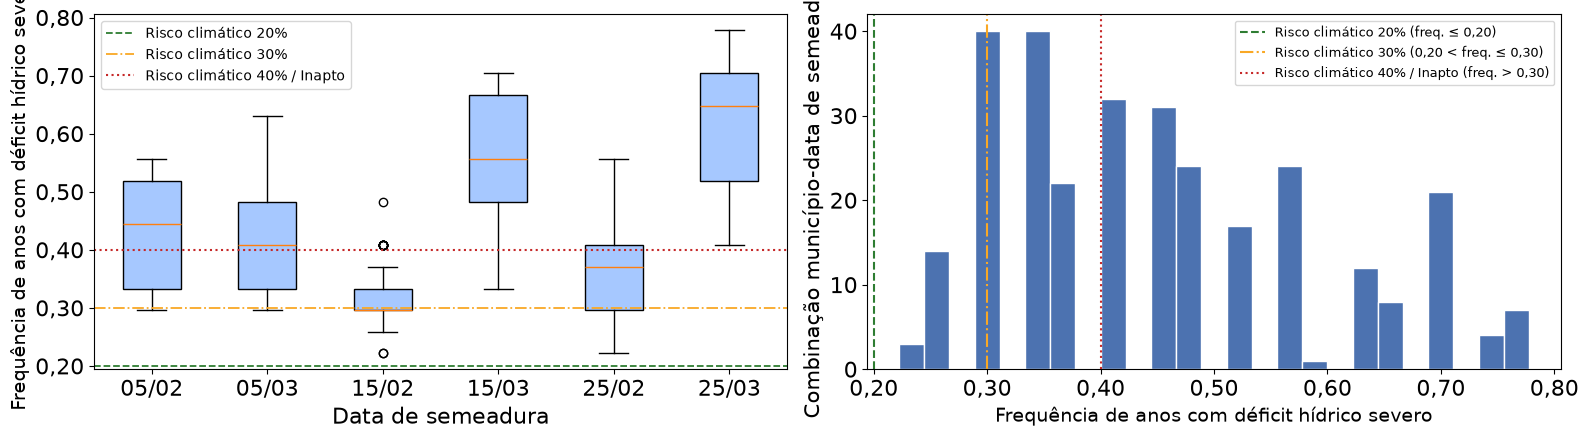

risco_climatico
Inapto (risco > 40%)    181
Risco climático 40%      62
Risco climático 30%      57
Name: count, dtype: int64


In [6]:
def formatar_virgula(x, pos):
    return f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

ordem_datas = sorted(risco_clima["data_semeadura"].unique())

# Limiares oficiais do ZARC (Portaria SPA/MAPA nº 329/2026) sobre a frequência de anos com
# déficit hídrico severo — quanto MAIOR a frequência, PIOR (inverso do ISNA médio antigo).
LIMIAR_20 = 0.20
LIMIAR_30 = 0.30
LIMIAR_40 = 0.40
COR_20 = "#2E7D32"   # verde — fronteira do risco climático 20% (melhor)
COR_30 = "#F9A825"   # âmbar — fronteira do risco climático 30%
COR_40 = "#C62828"   # vermelho — fronteira do risco climático 40% / inapto

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4.5))

# ========== PAINEL ESQUERDO: BOXPLOT ==========
dados_boxplot = [risco_clima.loc[risco_clima["data_semeadura"] == d, "freq_evento_adverso"] for d in ordem_datas]
bp = ax1.boxplot(dados_boxplot, tick_labels=ordem_datas, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#a6c8ff")

ax1.axhline(LIMIAR_20, color=COR_20, linestyle="--", linewidth=1.3, label="Risco climático 20%")
ax1.axhline(LIMIAR_30, color=COR_30, linestyle="-.", linewidth=1.3, label="Risco climático 30%")
ax1.axhline(LIMIAR_40, color=COR_40, linestyle=":", linewidth=1.5, label="Risco climático 40% / Inapto")
ax1.set_xlabel("Data de semeadura", fontsize=16)
ax1.set_ylabel("Frequência de anos com déficit hídrico severo", fontsize=14)
ax1.legend()
ax1.tick_params(axis="x", labelsize=16)
ax1.tick_params(axis="y", labelsize=16)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(formatar_virgula))

# ========== PAINEL DIREITO: HISTOGRAMA ==========
ax2.hist(risco_clima["freq_evento_adverso"], bins=25, color="#4C72B0", edgecolor="white")

ax2.axvline(LIMIAR_20, color=COR_20, linestyle="--", label="Risco climático 20% (freq. ≤ 0,20)")
ax2.axvline(LIMIAR_30, color=COR_30, linestyle="-.", label="Risco climático 30% (0,20 < freq. ≤ 0,30)")
ax2.axvline(LIMIAR_40, color=COR_40, linestyle=":", label="Risco climático 40% / Inapto (freq. > 0,30)")

ax2.set_xlabel("Frequência de anos com déficit hídrico severo", fontsize=14)
ax2.set_ylabel("Combinação município-data de semeadura", fontsize=15)
ax2.legend(loc="upper right", fontsize=9)
ax2.tick_params(axis="x", labelsize=16)
ax2.tick_params(axis="y", labelsize=16)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(formatar_virgula))

plt.tight_layout()
plt.show()

# Contagem de combinações por classe de risco climático
print(risco_clima["risco_climatico"].value_counts())

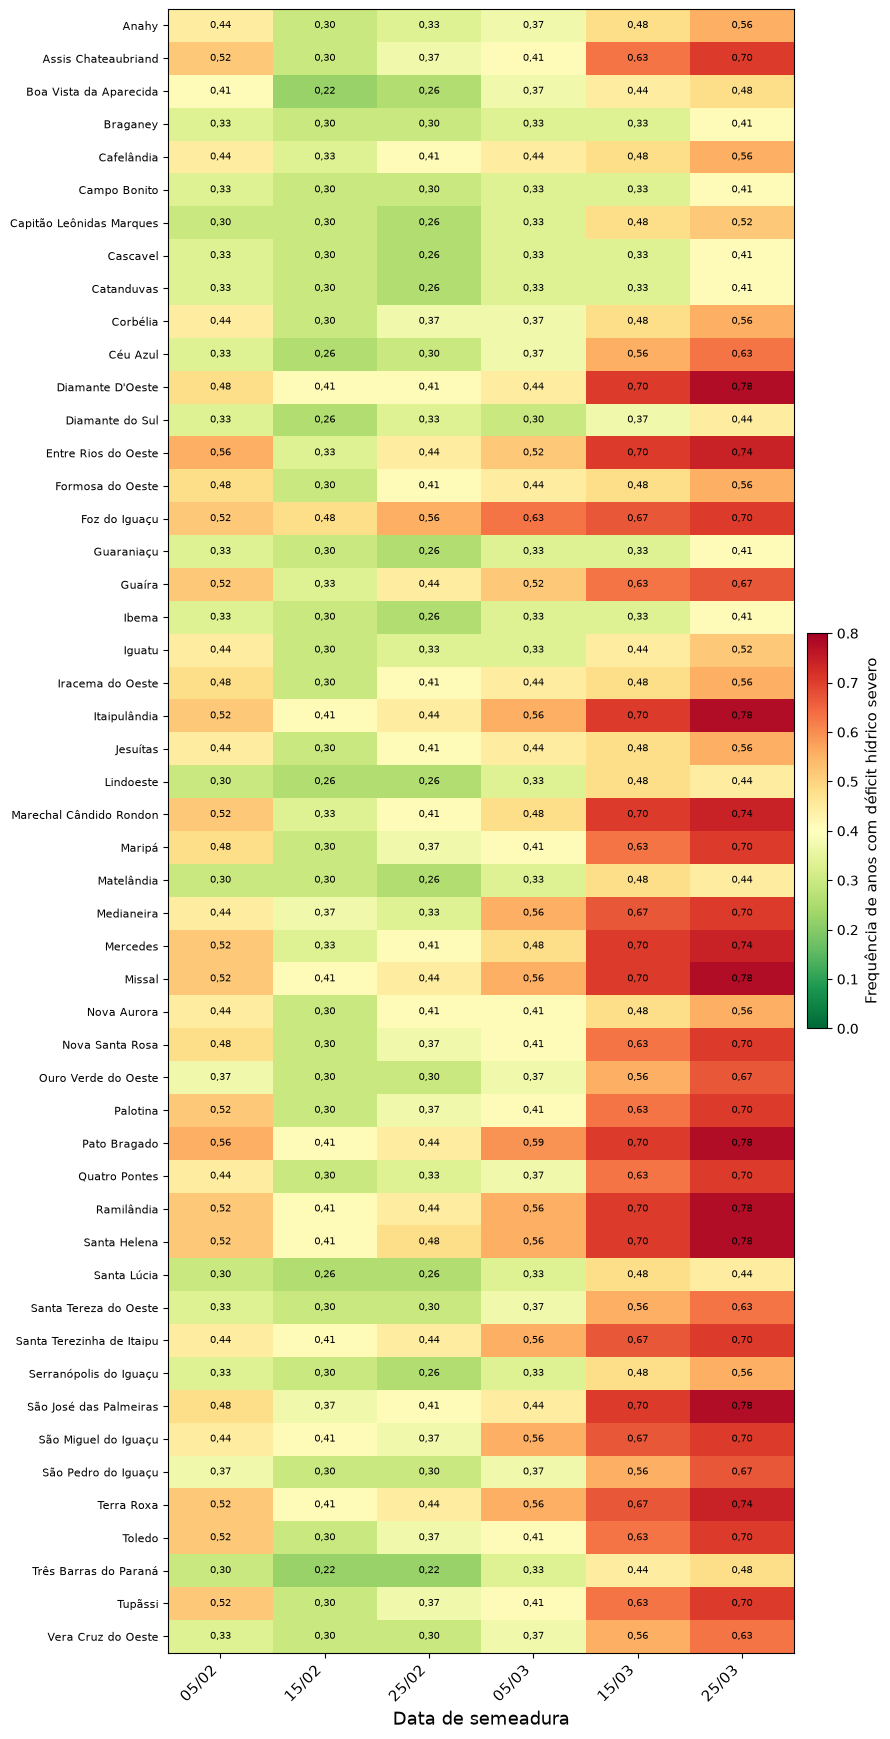

In [7]:
# Ordem cronológica (a ordenação alfabética anterior misturava fevereiro e março por dia)
SEM = ["05/02", "15/02", "25/02", "05/03", "15/03", "25/03"]
pivot_risco_clima = risco_clima.pivot(index="municipio", columns="data_semeadura", values="freq_evento_adverso")[SEM]

fig, ax = plt.subplots(figsize=(9, max(6, 0.35 * len(pivot_risco_clima))))
im = ax.imshow(pivot_risco_clima, cmap="RdYlGn_r", vmin=0, vmax=0.8, aspect="auto")

ax.set_xticks(range(len(SEM)))
ax.set_xticklabels(SEM, rotation=45, ha="right", fontsize=11)
ax.set_yticks(range(len(pivot_risco_clima.index)))
ax.set_yticklabels(pivot_risco_clima.index, fontsize=8)

for i in range(pivot_risco_clima.shape[0]):
    for j in range(pivot_risco_clima.shape[1]):
        v = pivot_risco_clima.iloc[i, j]
        if pd.notna(v):
            ax.text(j, i, formatar_virgula(v, None), ha="center", va="center", fontsize=7)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Frequência de anos com déficit hídrico severo", fontsize=11)

ax.set_xlabel("Data de semeadura", fontsize=13)
plt.tight_layout()
plt.show()

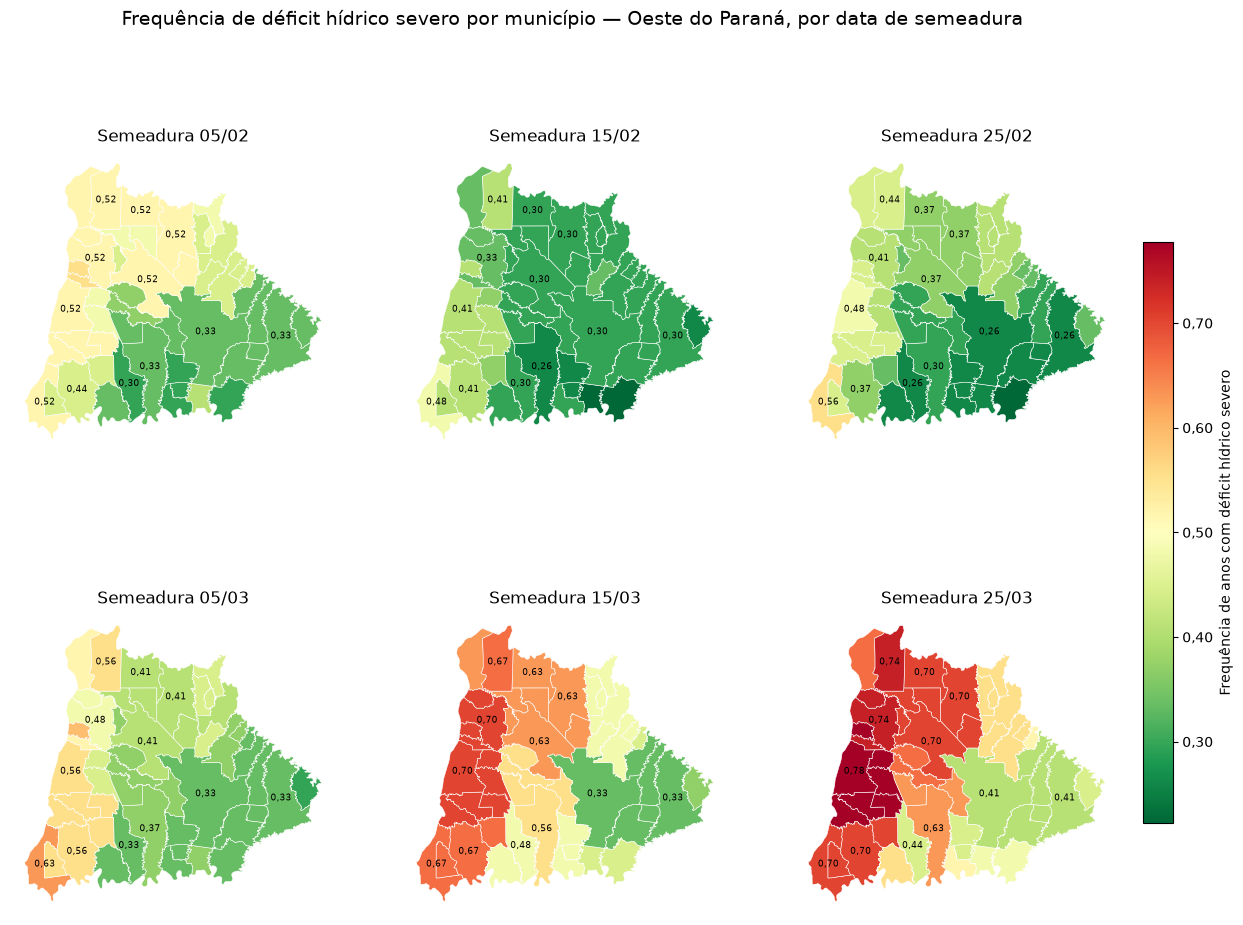

In [8]:
# Multiplot de mapas — frequência de déficit hídrico severo por município, uma para cada
# data de semeadura (usando os polígonos municipais do IBGE via geobr).
muni_pr = geobr.read_municipality(code_muni="PR", year=2020)
muni_pr["nome_norm"] = muni_pr["name_muni"].apply(lambda x: unidecode.unidecode(x).upper())
risco_clima["nome_norm"] = risco_clima["municipio"].apply(lambda x: unidecode.unidecode(x).upper())

oeste_geo = muni_pr[muni_pr["nome_norm"].isin(risco_clima["nome_norm"].unique())].copy()
oeste_geo["area_km2"] = oeste_geo.geometry.to_crs(oeste_geo.estimate_utm_crs()).area / 1e6

# Anota o valor só nos municípios com área grande o suficiente pra caber o texto — em polígonos
# pequenos o número fica ilegível/sobreposto.
N_ANOTAR = 12
municipios_para_anotar = oeste_geo.nlargest(N_ANOTAR, "area_km2")["nome_norm"].tolist()

vmin = risco_clima["freq_evento_adverso"].min()
vmax = risco_clima["freq_evento_adverso"].max()

fig, axes = plt.subplots(2, 3, figsize=(15, 11))
axes = axes.flatten()

for ax, data in zip(axes, SEM):
    dados_data = risco_clima.loc[risco_clima["data_semeadura"] == data, ["nome_norm", "freq_evento_adverso"]]
    gdf = oeste_geo.merge(dados_data, on="nome_norm", how="left")
    gdf.plot(
        column="freq_evento_adverso", cmap="RdYlGn_r", vmin=vmin, vmax=vmax,
        edgecolor="white", linewidth=0.4, ax=ax, missing_kwds={"color": "lightgrey"},
    )
    ax.set_title(f"Semeadura {data}", fontsize=12)
    ax.set_axis_off()

    anotar = gdf[gdf["nome_norm"].isin(municipios_para_anotar)]
    for _, row in anotar.iterrows():
        if pd.isna(row["freq_evento_adverso"]):
            continue
        centroide = row.geometry.centroid
        ax.annotate(
            formatar_virgula(row["freq_evento_adverso"], None),
            xy=(centroide.x, centroide.y), ha="center", va="center",
            fontsize=6.5, color="black",
        )

sm = plt.cm.ScalarMappable(cmap="RdYlGn_r", norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), fraction=0.025, pad=0.02, location="right")
cbar.set_label("Frequência de anos com déficit hídrico severo")
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatar_virgula))

fig.suptitle(
    "Frequência de déficit hídrico severo por município — Oeste do Paraná, por data de semeadura",
    y=0.97, fontsize=14,
)
plt.show()

## 4. Risco econômico — cenário Custo Operacional (CONAB)

Único cenário usado neste notebook (`09b`) — sem comparação com 100%/rateio 50%/proporcional.

In [9]:
risco_economico

,municipio,data_semeadura,n_anos,pct_anos_cobre_custo,margem_media_rs_ha,risco_economico
0,Anahy,05/02,26,50.0,55.251153,Viabilidade intermediária
1,Anahy,05/03,26,50.0,58.408038,Mais viável
2,Anahy,15/02,26,50.0,43.955165,Viabilidade intermediária
3,Anahy,15/03,26,50.0,55.544123,Viabilidade intermediária
4,Anahy,25/02,26,50.0,54.759383,Viabilidade intermediária
...,...,...,...,...,...,...
295,Vera Cruz do Oeste,05/03,26,50.0,75.655866,Mais viável
296,Vera Cruz do Oeste,15/02,26,50.0,39.336438,Viabilidade intermediária
297,Vera Cruz do Oeste,15/03,26,46.2,57.933584,Mais viável
298,Vera Cruz do Oeste,25/02,26,50.0,67.604680,Mais viável


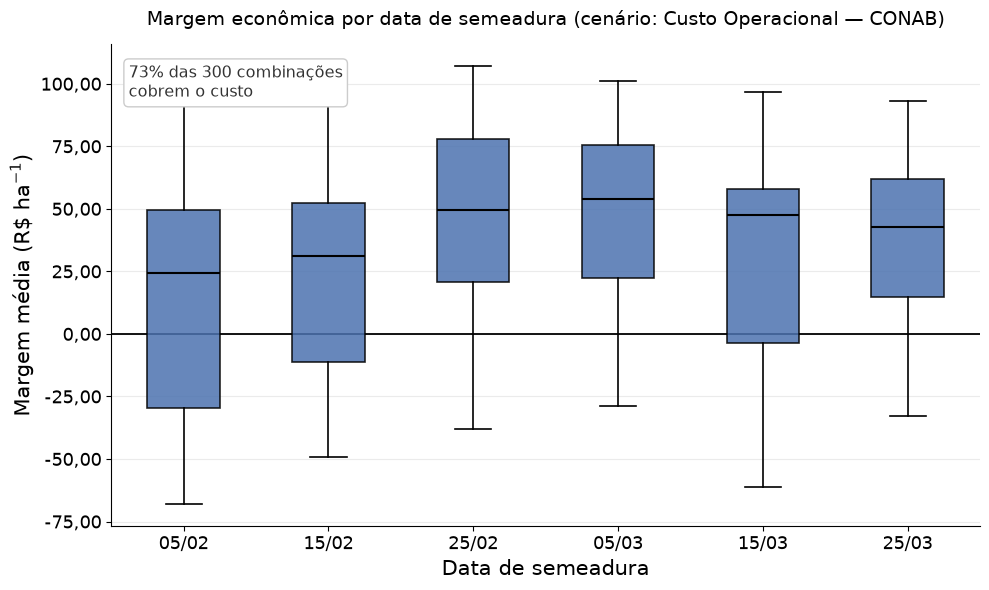

In [10]:
# Distribuição da margem econômica (cenário Operacional CONAB) por data de semeadura
dados_boxplot_econ = [risco_economico.loc[risco_economico["data_semeadura"] == d, "margem_media_rs_ha"] for d in SEM]

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(
    dados_boxplot_econ, tick_labels=SEM, patch_artist=True, widths=0.5,
    medianprops={"color": "black", "linewidth": 1.5}, boxprops={"linewidth": 1.2},
    whiskerprops={"linewidth": 1.2}, capprops={"linewidth": 1.2},
)
for patch in bp["boxes"]:
    patch.set_facecolor("#4C72B0")
    patch.set_alpha(0.85)

ax.axhline(0, color="black", linewidth=1.3, zorder=1)

ax.grid(axis="y", alpha=0.25, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.set_ylabel(r"Margem média (R\$ ha$^{-1}$)", fontsize=15)
ax.set_xlabel("Data de semeadura", fontsize=15)
ax.set_title("Margem econômica por data de semeadura (cenário: Custo Operacional — CONAB)", fontsize=14, pad=14)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatar_virgula))
ax.tick_params(axis="both", labelsize=13)

pct_cobre_geral = 100 * (risco_economico["margem_media_rs_ha"] >= 0).mean()
ax.annotate(
    f"{pct_cobre_geral:.0f}% das 300 combinações\ncobrem o custo",
    xy=(0.02, 0.96), xycoords="axes fraction", ha="left", va="top",
    fontsize=11.5, color="#333333",
    bbox={"boxstyle": "round", "facecolor": "white", "edgecolor": "#cccccc"},
)

plt.tight_layout()
plt.show()

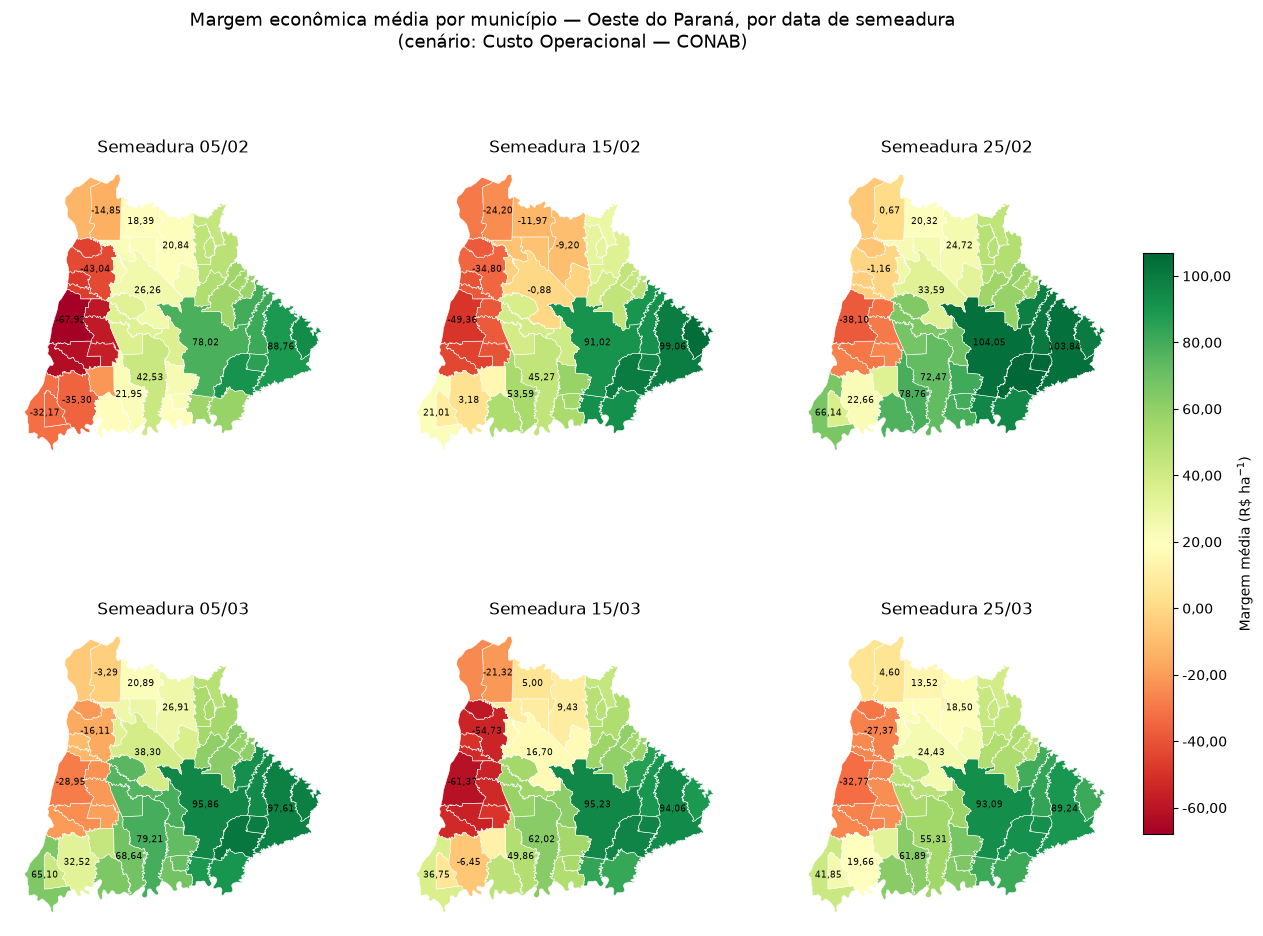

In [11]:
# Multiplot de mapas: margem econômica média por município, uma para cada data de
# semeadura (cenário: Custo Operacional — CONAB).
risco_economico["nome_norm"] = risco_economico["municipio"].apply(lambda x: unidecode.unidecode(x).upper())

vmin_econ = risco_economico["margem_media_rs_ha"].min()
vmax_econ = risco_economico["margem_media_rs_ha"].max()

fig, axes = plt.subplots(2, 3, figsize=(15, 11))
axes = axes.flatten()

for ax, data in zip(axes, SEM):
    dados_data = risco_economico.loc[risco_economico["data_semeadura"] == data, ["nome_norm", "margem_media_rs_ha"]]
    gdf = oeste_geo.merge(dados_data, on="nome_norm", how="left")
    gdf.plot(
        column="margem_media_rs_ha", cmap="RdYlGn", vmin=vmin_econ, vmax=vmax_econ,
        edgecolor="white", linewidth=0.4, ax=ax, missing_kwds={"color": "lightgrey"},
    )
    ax.set_title(f"Semeadura {data}", fontsize=12)
    ax.set_axis_off()

    anotar = gdf[gdf["nome_norm"].isin(municipios_para_anotar)]
    for _, row in anotar.iterrows():
        if pd.isna(row["margem_media_rs_ha"]):
            continue
        centroide = row.geometry.centroid
        ax.annotate(
            formatar_virgula(row["margem_media_rs_ha"], None),
            xy=(centroide.x, centroide.y), ha="center", va="center",
            fontsize=6.5, color="black",
        )

sm = plt.cm.ScalarMappable(cmap="RdYlGn", norm=plt.Normalize(vmin=vmin_econ, vmax=vmax_econ))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), fraction=0.025, pad=0.02, location="right")
cbar.set_label(r"Margem média (R\$ ha$^{-1}$)")
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatar_virgula))

fig.suptitle(
    "Margem econômica média por município — Oeste do Paraná, por data de semeadura\n(cenário: Custo Operacional — CONAB)",
    y=0.98, fontsize=13,
)
plt.show()

## 5. PCA — componente agroclimático

O PCA (`10b`, seção 5) reduz o ISNA médio e a produtividade prevista média — fortemente
correlacionados (Pearson r≈0,85) — a um único componente agroclimático, evitando ponderar o
componente hídrico duas vezes. Não depende do cenário de custo (usa só clima + produtividade).

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Recalcula o PCA aqui (mesma padronização e mesma correção de sinal do Notebook 10b, Seção 5) só
# para extrair a variância explicada e os pesos (loadings) por componente — o
# componente_agroclimatico em si já vem pronto em matriz_topsis.
X_pca = StandardScaler().fit_transform(matriz_topsis[["isna_medio", "produtividade_media_kg_ha"]].to_numpy())
pca_diag = PCA(n_components=2)
componentes_pca = pca_diag.fit_transform(X_pca)
pc1 = componentes_pca[:, 0]

if np.corrcoef(pc1, matriz_topsis["produtividade_media_kg_ha"])[0, 1] < 0:
    pc1 = -pc1
    pca_diag.components_[0] = -pca_diag.components_[0]

corr_check = np.corrcoef(pc1, matriz_topsis["componente_agroclimatico"])[0, 1]
print(f"Correlação entre PC1 recalculado e componente_agroclimatico (Notebook 10b): {corr_check:.4f}")
print(f"Variância explicada — PC1: {pca_diag.explained_variance_ratio_[0]:.1%}, PC2: {pca_diag.explained_variance_ratio_[1]:.1%}")

Correlação entre PC1 recalculado e componente_agroclimatico (Notebook 10b): 1.0000
Variância explicada — PC1: 92.5%, PC2: 7.5%


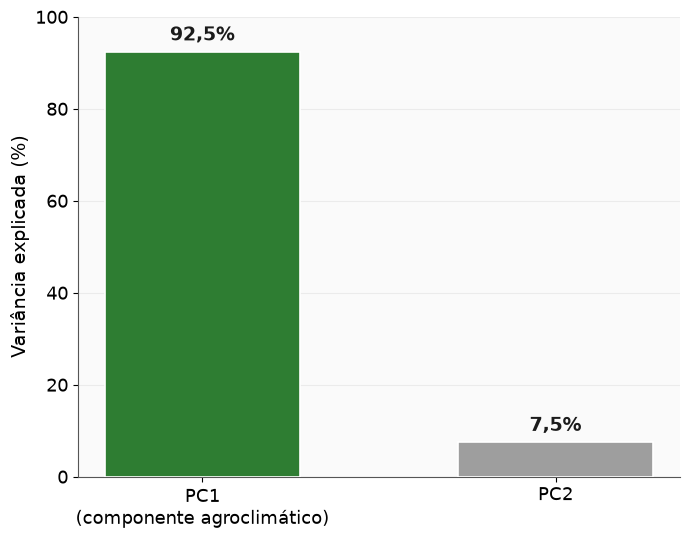

In [13]:
# Gráfico A — variância explicada por componente (scree plot)
variancia_pct = pca_diag.explained_variance_ratio_ * 100
labels_pc = ["PC1\n(componente agroclimático)", "PC2"]
cores_pc = ["#2E7D32", "#9E9E9E"]

def fmt_br(valor, casas=1):
    '''Formata número no padrão brasileiro (vírgula decimal).'''
    return f"{valor:.{casas}f}".replace(".", ",")

fig, ax = plt.subplots(figsize=(7, 5.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("#FAFAFA")

barras = ax.bar(
    labels_pc, variancia_pct, color=cores_pc, edgecolor="white",
    linewidth=1.2, width=0.55, zorder=3,
)

for barra, valor in zip(barras, variancia_pct):
    ax.annotate(
        f"{fmt_br(valor)}%",
        xy=(barra.get_x() + barra.get_width() / 2, valor),
        xytext=(0, 8), textcoords="offset points",
        ha="center", fontsize=14, fontweight="bold", color="#1B1B1B",
    )

ax.set_ylabel("Variância explicada (%)", fontsize=14)
ax.set_ylim(0, 100)
ax.tick_params(labelsize=13)
ax.grid(axis="y", alpha=0.2, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#555555")

plt.tight_layout()
plt.show()

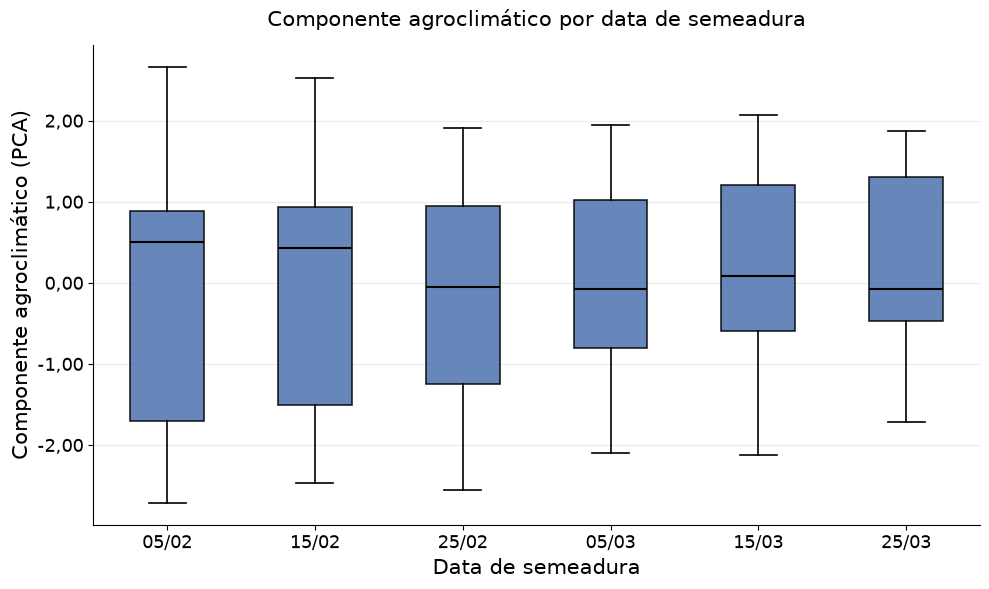

In [14]:
# Gráfico B — componente agroclimático por data de semeadura
dados_boxplot_pca = [matriz_topsis.loc[matriz_topsis["data_semeadura"] == d, "componente_agroclimatico"] for d in SEM]

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(
    dados_boxplot_pca, tick_labels=SEM, patch_artist=True, widths=0.5,
    medianprops={"color": "black", "linewidth": 1.5}, boxprops={"linewidth": 1.2},
    whiskerprops={"linewidth": 1.2}, capprops={"linewidth": 1.2},
)
for patch in bp["boxes"]:
    patch.set_facecolor("#4C72B0")
    patch.set_alpha(0.85)

ax.set_ylabel("Componente agroclimático (PCA)", fontsize=15)
ax.set_xlabel("Data de semeadura", fontsize=15)
ax.set_title("Componente agroclimático por data de semeadura", fontsize=15, pad=14)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(labelsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatar_virgula))
plt.tight_layout()
plt.show()

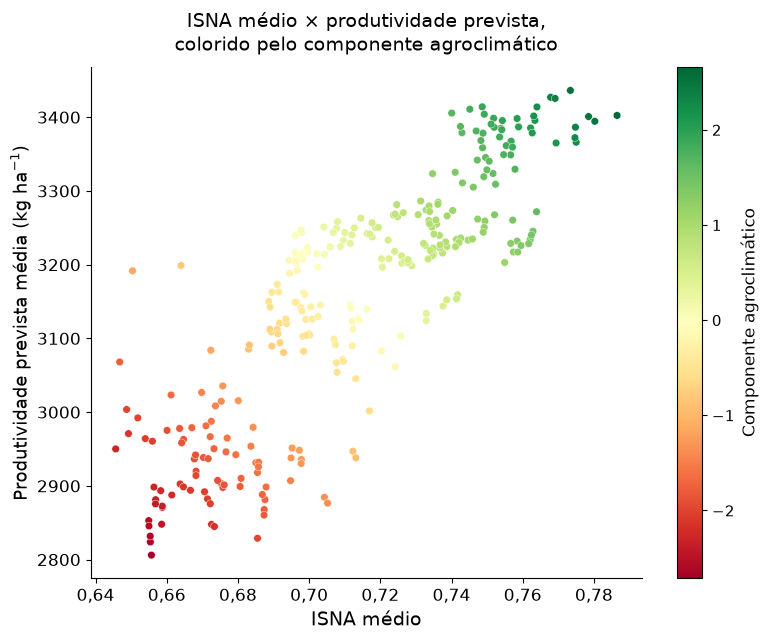

In [15]:
# Gráfico C — ISNA médio × produtividade prevista, colorido pelo componente agroclimático
fig, ax = plt.subplots(figsize=(8, 6.5))
sc = ax.scatter(
    matriz_topsis["isna_medio"], matriz_topsis["produtividade_media_kg_ha"],
    c=matriz_topsis["componente_agroclimatico"], cmap="RdYlGn", s=30, edgecolor="white", linewidth=0.3,
)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Componente agroclimático", fontsize=12)
cbar.ax.tick_params(labelsize=11)

ax.set_xlabel("ISNA médio", fontsize=14)
ax.set_ylabel("Produtividade prevista média (kg ha$^{-1}$)", fontsize=13)
ax.set_title("ISNA médio × produtividade prevista,\ncolorido pelo componente agroclimático", fontsize=14, pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(formatar_virgula))
ax.tick_params(labelsize=12)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

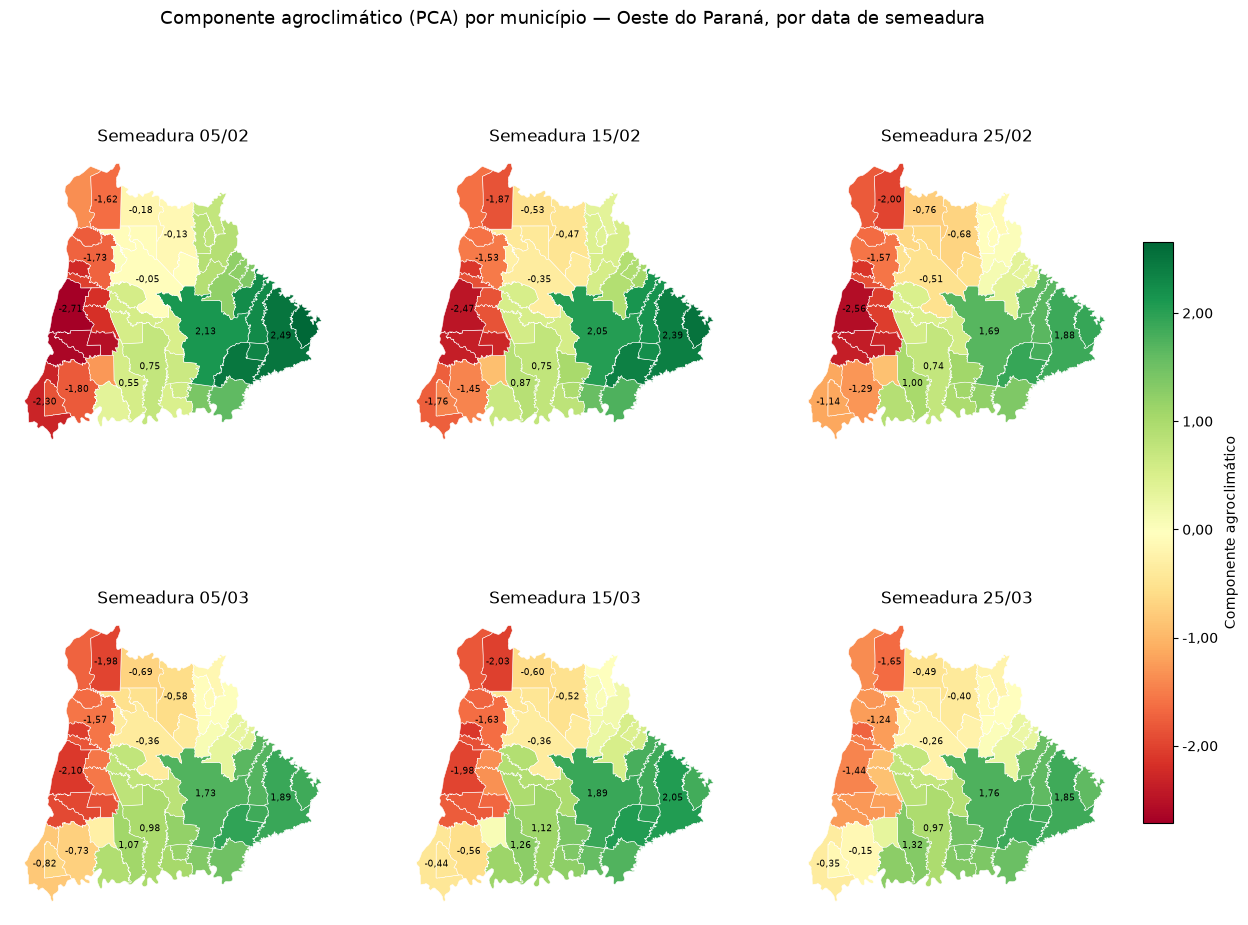

In [16]:
# Gráfico E — multiplot de mapas: componente agroclimático por município, uma para cada data
# de semeadura.
matriz_topsis["nome_norm"] = matriz_topsis["municipio"].apply(lambda x: unidecode.unidecode(x).upper())

vmin_pca = matriz_topsis["componente_agroclimatico"].min()
vmax_pca = matriz_topsis["componente_agroclimatico"].max()

fig, axes = plt.subplots(2, 3, figsize=(15, 11))
axes = axes.flatten()

for ax, data in zip(axes, SEM):
    dados_data = matriz_topsis.loc[matriz_topsis["data_semeadura"] == data, ["nome_norm", "componente_agroclimatico"]]
    gdf = oeste_geo.merge(dados_data, on="nome_norm", how="left")
    gdf.plot(
        column="componente_agroclimatico", cmap="RdYlGn", vmin=vmin_pca, vmax=vmax_pca,
        edgecolor="white", linewidth=0.4, ax=ax, missing_kwds={"color": "lightgrey"},
    )
    ax.set_title(f"Semeadura {data}", fontsize=12)
    ax.set_axis_off()

    anotar = gdf[gdf["nome_norm"].isin(municipios_para_anotar)]
    for _, row in anotar.iterrows():
        if pd.isna(row["componente_agroclimatico"]):
            continue
        centroide = row.geometry.centroid
        ax.annotate(
            formatar_virgula(row["componente_agroclimatico"], None),
            xy=(centroide.x, centroide.y), ha="center", va="center",
            fontsize=6.5, color="black",
        )

sm = plt.cm.ScalarMappable(cmap="RdYlGn", norm=plt.Normalize(vmin=vmin_pca, vmax=vmax_pca))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), fraction=0.025, pad=0.02, location="right")
cbar.set_label("Componente agroclimático")
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatar_virgula))

fig.suptitle(
    "Componente agroclimático (PCA) por município — Oeste do Paraná, por data de semeadura",
    y=0.97, fontsize=13,
)
plt.show()

## 6. TOPSIS — resultados multicritério

O TOPSIS (`10b`, seção 6) combina o componente agroclimático (PCA) e a margem econômica — só do
cenário Custo Operacional (CONAB) — em um único score contínuo (0 a 1).

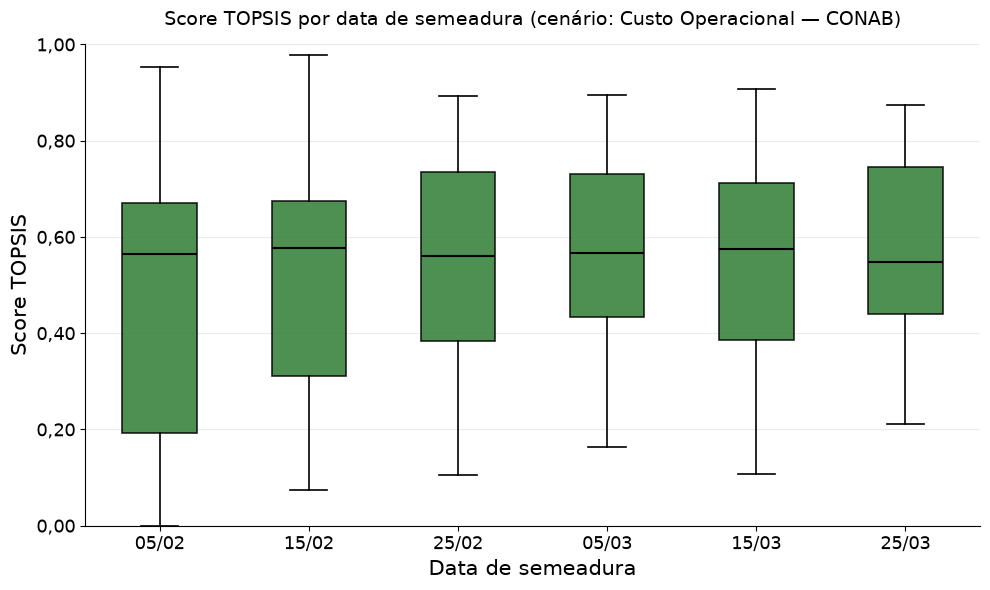

In [17]:
# Boxplot do score TOPSIS por data de semeadura (cenário: Custo Operacional — CONAB)
dados_boxplot_topsis = [matriz_topsis.loc[matriz_topsis["data_semeadura"] == d, "topsis_score"] for d in SEM]

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(
    dados_boxplot_topsis, tick_labels=SEM, patch_artist=True, widths=0.5,
    medianprops={"color": "black", "linewidth": 1.5}, boxprops={"linewidth": 1.2},
    whiskerprops={"linewidth": 1.2}, capprops={"linewidth": 1.2},
)
for patch in bp["boxes"]:
    patch.set_facecolor("#2E7D32")
    patch.set_alpha(0.85)

ax.set_ylabel("Score TOPSIS", fontsize=15)
ax.set_xlabel("Data de semeadura", fontsize=15)
ax.set_title("Score TOPSIS por data de semeadura (cenário: Custo Operacional — CONAB)", fontsize=14, pad=14)
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(labelsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatar_virgula))
plt.tight_layout()
plt.show()

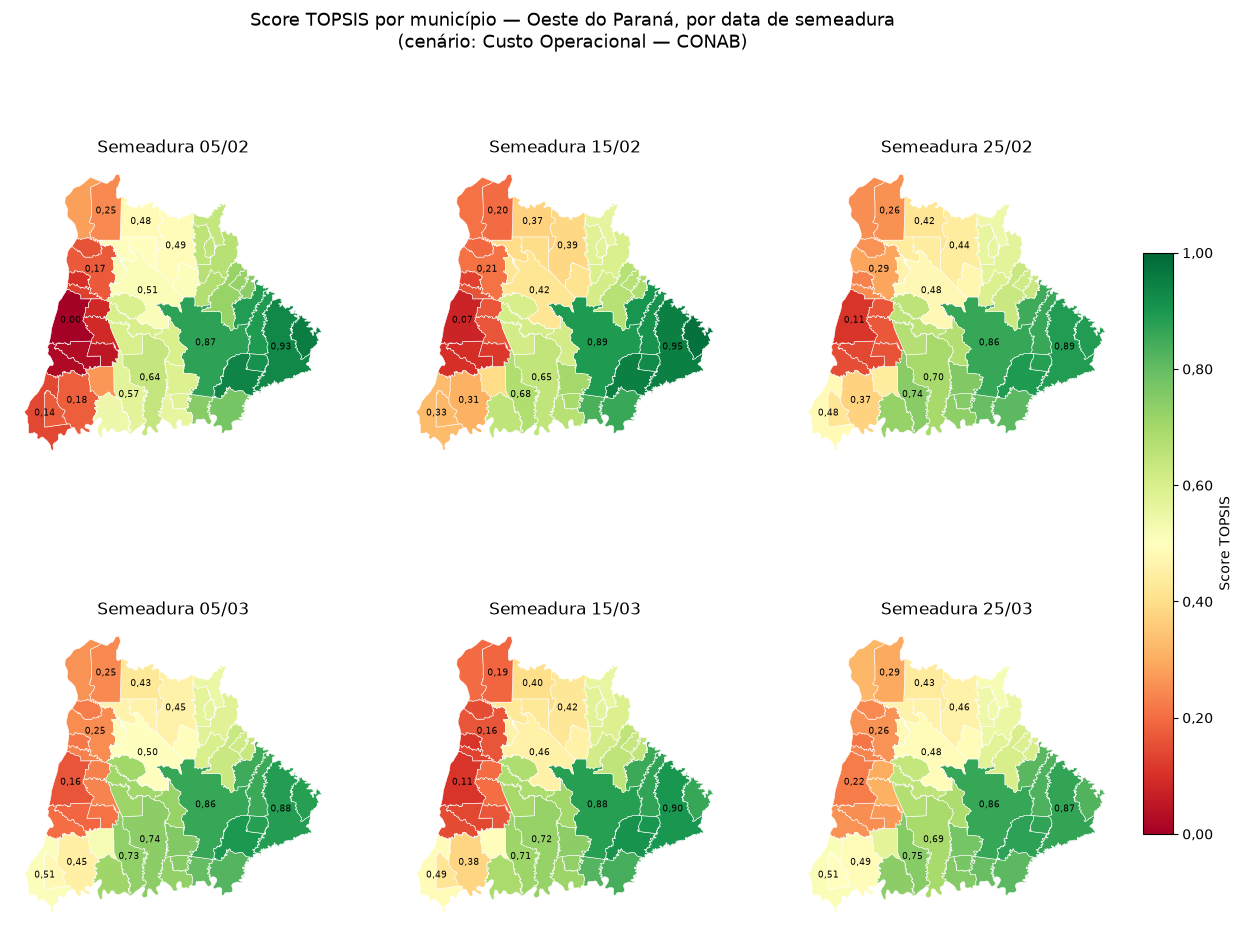

In [18]:
# Multiplot de mapas: score TOPSIS por município, uma para cada data de semeadura
# (cenário: Custo Operacional — CONAB).
vmin_topsis, vmax_topsis = 0, 1

fig, axes = plt.subplots(2, 3, figsize=(15, 11))
axes = axes.flatten()

for ax, data in zip(axes, SEM):
    dados_data = matriz_topsis.loc[matriz_topsis["data_semeadura"] == data, ["nome_norm", "topsis_score"]]
    gdf = oeste_geo.merge(dados_data, on="nome_norm", how="left")
    gdf.plot(
        column="topsis_score", cmap="RdYlGn", vmin=vmin_topsis, vmax=vmax_topsis,
        edgecolor="white", linewidth=0.4, ax=ax, missing_kwds={"color": "lightgrey"},
    )
    ax.set_title(f"Semeadura {data}", fontsize=12)
    ax.set_axis_off()

    anotar = gdf[gdf["nome_norm"].isin(municipios_para_anotar)]
    for _, row in anotar.iterrows():
        if pd.isna(row["topsis_score"]):
            continue
        centroide = row.geometry.centroid
        ax.annotate(
            formatar_virgula(row["topsis_score"], None),
            xy=(centroide.x, centroide.y), ha="center", va="center",
            fontsize=6.5, color="black",
        )

sm = plt.cm.ScalarMappable(cmap="RdYlGn", norm=plt.Normalize(vmin=vmin_topsis, vmax=vmax_topsis))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), fraction=0.025, pad=0.02, location="right")
cbar.set_label("Score TOPSIS")
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatar_virgula))

fig.suptitle(
    "Score TOPSIS por município — Oeste do Paraná, por data de semeadura\n(cenário: Custo Operacional — CONAB)",
    y=0.98, fontsize=13,
)
plt.show()